<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_03_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

# Problem 1:

Scenario:
A data scientist writes the following code:

### from sklearn.impute import SimpleImputer

### from sklearn.model_selection import train_test_split

### df = pd.read_csv('data.csv')

### imputer = SimpleImputer(strategy='median')

### df[['Age', 'Salary']] = imputer.fit_transform(df[['Age', 'Salary']])

### X = df.drop('Target', axis=1)

### y = df['Target']

### X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



Question: Identify the data leakage issue. Explain why it is wrong and write the corrected code.

Ans : Data leakage occurs because the imputer computes the median from the entire dataset (train + test) before the split. This means test set statistics "leak" into the training process, giving an overly optimistic and unrealistic performance estimate — in production, you'd never have test/future data available during training.

In [ ]:
# Corrected Code

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('data.csv')

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


imputer = SimpleImputer(strategy='median')

imputer.fit(X_train[['Age', 'Salary']])

X_train[['Age', 'Salary']] = imputer.transform(X_train[['Age', 'Salary']])
X_test[['Age', 'Salary']] = imputer.transform(X_test[['Age', 'Salary']])

# Problem 2:
Question: Using the provided data.csv file, write code to find:
- Total missing values in each column
- Percentage of missing values per column
- Which columns have more than 50% missing values?


In [ ]:
# Total missing values in each column
df.isnull().sum()

# Percentage of missing values per column
(df.isnull().sum() / len(df) * 100).sort_values()

# Which columns have more than 50% missing values?
missing_val = df.columns[df.isnull().mean() > 0.5].tolist()

missing_val

['Cabin']

# Problem 3:

Question: Look at the Temperature column in data.csv. It contains:
- Numeric values like 22.5, 18.6
- String 'Unknown'
- NaN values
- Write code to handle this column properly before imputation.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')

# Replace 'Unknown' with NaN, then convert column to numbers
df['Temperature'] = df['Temperature'].replace('Unknown', np.nan)
df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')

# Fill NaN with the mean
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].mean())

print(df['Temperature'])

0      15.100000
1      28.300000
2      22.000000
3      22.700000
4      22.469605
         ...    
995    17.000000
996    17.000000
997    24.700000
998    22.469605
999    14.100000
Name: Temperature, Length: 1000, dtype: float64


# Problem 4:
Question: For the Diagnosis column in data.csv, implement imputation with:
- Constant strategy using 'Missing' string
- Add a missing indicator column

Write the complete code using SimpleImputer.



In [ ]:

# diag_imputer = SimpleImputer(missing_values = np.nan, strategy = 'constant', fill_value='Missing', add_indicator = True)

# diag_imputer.fit(df[['Diagnosis']])
# df[['Diagnosis']] = diag_imputer.transform(df[['Diagnosis']])

# df


diag_imputer = SimpleImputer(missing_values = np.nan, strategy = 'constant', fill_value='Missing', add_indicator = True)

diag_imputer.fit(df[['Cabin']])
df[['Cabin', 'Cabin_Missing_col']] = diag_imputer.transform(df[['Cabin']])

df

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target,Cabin_Missing_col
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.100000,Dhaka,Unknown,A,"SimpleImputer(add_indicator=True, fill_value='...",Missing,S,Male,0,280.32,True
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.300000,Chittagong,C,C,"SimpleImputer(add_indicator=True, fill_value='...",Missing,S,Female,1,314.83,True
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.000000,Sylhet,A,C,"SimpleImputer(add_indicator=True, fill_value='...",Missing,C,Female,0,252.43,True
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.700000,Rajshahi,C,B,"SimpleImputer(add_indicator=True, fill_value='...",Missing,S,Female,0,239.21,True
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,22.469605,Rajshahi,A,C,"SimpleImputer(add_indicator=True, fill_value='...",Missing,S,Female,0,179.51,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.000000,Dhaka,A,C,"SimpleImputer(add_indicator=True, fill_value='...",Missing,C,Female,0,309.92,True
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.000000,Sylhet,A,C,"SimpleImputer(add_indicator=True, fill_value='...",Cabin_D,S,Male,0,222.41,False
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.700000,Rajshahi,C,B,"SimpleImputer(add_indicator=True, fill_value='...",Missing,S,Female,0,221.89,True
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,22.469605,Rajshahi,B,B,"SimpleImputer(add_indicator=True, fill_value='...",Missing,Q,Female,0,293.69,True


# Problem 5:
Question: Using the Age column from data.csv:
- Calculate mean and median from training data only
- Create two new columns: Age_mean_imputed and Age_median_imputed
- Plot KDE for both to compare distributions
Which one would you choose and why?


In [ ]:
age_mean = X_train['Age'].mean()
age_median = X_train['Age'].median()

X_train['Age_mean_imputed'] = X_train['Age'].fillna(age_mean)
X_train['Age_median_imputed'] = X_train['Age'].fillna(age_median)


In [ ]:
X_train

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Price_Target,Age_mean_imputed,Age_median_imputed
630,14.0,NaN,68272.0,4.2,81551.0,NaN,276610.0,3018,22.4,Dhaka,Unknown,C,Type2,NaN,C,Male,253.41,14.0,14.0
838,46.0,NaN,66146.0,5.0,NaN,2.0,433043.0,2265,20.3,Chittagong,A,A,NaN,Cabin_C,S,Male,307.87,46.0,46.0
513,24.0,5178.0,37453.0,4.4,NaN,2.0,302979.0,2205,19.7,Chittagong,Unknown,A,Type1,NaN,C,Male,267.74,24.0,24.0
234,60.0,18648.0,60898.0,4.5,129248.0,2.0,237408.0,2402,14.7,Chittagong,A,C,Type3,NaN,S,Female,243.34,60.0,60.0
171,25.0,26120.0,107066.0,3.3,69012.0,1.0,NaN,2367,22.6,Khulna,A,B,Type1,NaN,S,Male,190.05,25.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,41.0,3597.0,75586.0,2.8,105868.0,2.0,472796.0,2284,20.9,Chittagong,A,C,NaN,NaN,S,Female,256.67,41.0,41.0
327,44.0,158060.0,44967.0,2.5,36738.0,2.0,331412.0,1270,24.3,Sylhet,B,A,Type1,Cabin_B,S,Female,303.53,44.0,44.0
59,46.0,103345.0,44584.0,NaN,95705.0,2.0,263484.0,2169,26.1,Sylhet,C,C,Type1,Cabin_B,C,Male,251.13,46.0,46.0
918,29.0,64853.0,63739.0,3.4,89434.0,1.0,201213.0,2153,30.9,Chittagong,B,C,Type3,NaN,Q,Male,265.10,29.0,29.0


<Axes: xlabel='Age_mean_imputed', ylabel='Density'>

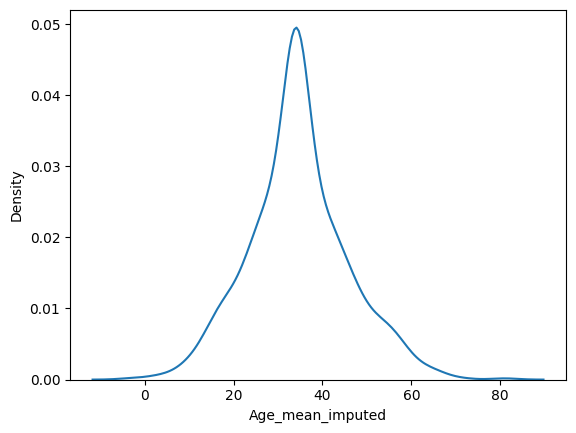

In [ ]:
sns.kdeplot(data = X_train, x = X_train['Age_mean_imputed'])

<Axes: xlabel='Age_median_imputed', ylabel='Density'>

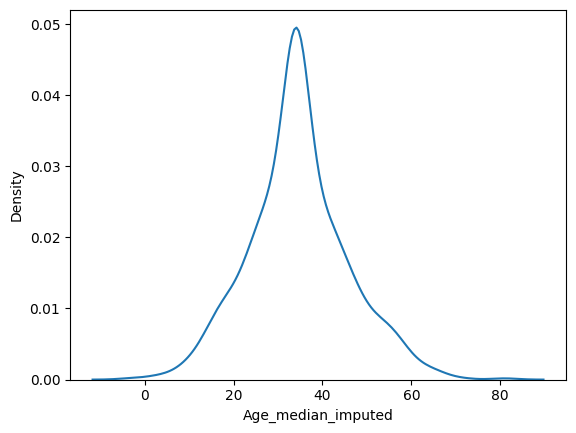

In [ ]:
sns.kdeplot(data = X_train, x = X_train['Age_median_imputed'])

Ans: I'd choose median imputation. Age is slightly right-skewed (a few older passengers pull the mean up), and the median is robust to outliers, so it preserves the original distribution's shape better than the mean.

# Problem 6:
Scenario:
You have a dataset with the following columns:


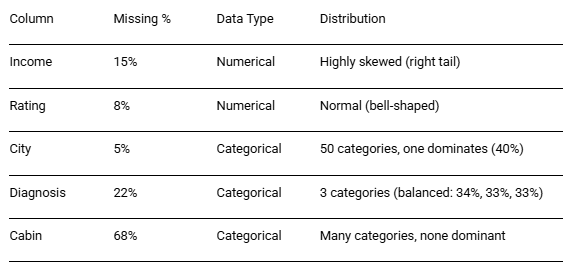

Question: For each column, recommend the BEST imputation strategy and justify your choice.



- 1. Income
— 15% missing, skewed
→ Use Median Some people earn way more than others, which pulls the mean up unfairly. Median ignores those extremes and gives a fairer "middle" value.

- 2. Rating — 8% missing, normal
→ Use Mean The data is nicely balanced (bell shape), so the mean sits right in the middle. Safe and simple.

- 3. City — 5% missing, one city dominates (40%)
→ Use Mode (most common city) Very few values are missing, and one city is already the most common. Filling with it barely changes anything.

- 4. Diagnosis — 22% missing, 3 equal categories
→ Predict it (using KNN or a model) All 3 categories are equal. If you just fill with the most common one, you'd unfairly make it bigger. Better to predict based on other columns.

- 5. Cabin — 68% missing, no clear winner
→ Make "Missing" its own category (or drop the column) Too much is missing to guess. Just label them as "Missing" — the fact that it's missing might itself be useful info. If not, drop the column.

# Problem 04 - Refined

Question: For the Diagnosis column in data.csv, implement imputation with:
- Constant strategy using 'Missing' string
- Add a missing indicator column

Write the complete code using SimpleImputer.


In [ ]:
df2 = pd.read_csv('data.csv')

df2['Diagnosis'].isnull().sum()

np.int64(220)

In [ ]:
diag_imputer2 = SimpleImputer(missing_values = np.nan, strategy = 'constant', fill_value='Missing', add_indicator=True)

diag_imputer2.fit(df2[['Diagnosis']])

df2[['Diagnosis', 'Diag_Imputed_col']] = diag_imputer2.transform(df2[['Diagnosis']])

df2

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target,Diag_Imputed_col
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,Missing,NaN,S,Male,0,280.32,True
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,1,314.83,False
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,0,252.43,False
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21,False
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,17.0,Dhaka,A,C,Type1,NaN,C,Female,0,309.92,False
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,17.0,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41,False
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,24.7,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89,False
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,Unknown,Rajshahi,B,B,Missing,NaN,Q,Female,0,293.69,True
